# `hsc_pz.ipynb` 

----------------

Inspects HSC p(z) based on the original paper (from their calibration)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from matplotlib import cm

(0.0, 3.0)

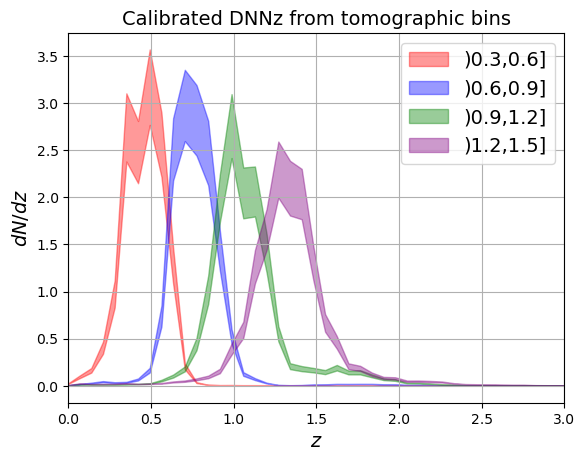

In [7]:
def error(expect, mids, num_samples = 1000): 
    var = (0.15 * expect)**2
    mu = np.log(expect**2/np.sqrt(var + expect**2))
    sig_2 = np.log(var/expect**2 + 1.)
    samples = multivariate_normal.rvs(mu, np.diag(sig_2), size=1000)
    pz = np.exp(samples)
    pz = np.array([el/np.trapz(el, mids) for el in pz])
    return pz, mu, np.diag(sig_2)

tomographic_binning_dnnz = np.loadtxt('data/tomographic_binning_dnnz.dat')

dnnz_t1, mu_t1, cov_t1 = error(tomographic_binning_dnnz[:, 1], tomographic_binning_dnnz[:, 0])
dnnz_t2, mu_t2, cov_t2 = error(tomographic_binning_dnnz[:, 2], tomographic_binning_dnnz[:, 0])
dnnz_t3, mu_t3, cov_t3 = error(tomographic_binning_dnnz[:, 3], tomographic_binning_dnnz[:, 0])
dnnz_t4, mu_t4, cov_t4 = error(tomographic_binning_dnnz[:, 4], tomographic_binning_dnnz[:, 0])

plt.fill_between(
    tomographic_binning_dnnz[:, 0], 
    np.percentile(dnnz_t1, 16, axis=0), 
    np.percentile(dnnz_t1, 84, axis=0), 
    color='red', 
    alpha=0.4, 
    label=')0.3,0.6]',
    )
plt.fill_between(
    tomographic_binning_dnnz[:, 0], 
    np.percentile(dnnz_t2, 16, axis=0), 
    np.percentile(dnnz_t2, 84, axis=0), 
    color='blue', 
    label=')0.6,0.9]',
    alpha=0.4
    )
plt.fill_between(
    tomographic_binning_dnnz[:, 0], 
    np.percentile(dnnz_t3, 16, axis=0), 
    np.percentile(dnnz_t3, 84, axis=0), 
    color='green', 
    label=')0.9,1.2]',
    alpha=0.4
    )
plt.fill_between(
    tomographic_binning_dnnz[:, 0], 
    np.percentile(dnnz_t4, 16, axis=0), 
    np.percentile(dnnz_t4, 84, axis=0), 
    color='purple', 
    label=')1.2,1.5]',
    alpha=0.4
    )
plt.grid()
plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$dN/dz$', fontsize=14)
plt.title('Calibrated DNNz from tomographic bins', fontsize=14)
plt.legend(fontsize=14)
plt.xlim(0, 3)